<a href="https://colab.research.google.com/github/farrelrassya/Practical-Statistics-for-Data-Scientist-Books/blob/main/PracticalStatisticsChapter5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Classification

> *Practical Statistics for Data Scientists, 3rd Edition*
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

Classification is perhaps the most important form of **supervised learning** in data science. The goal is to predict whether a record belongs to one category or another -- is an email phishing or legitimate? Will a customer churn or stay? Will a loan default or be paid off?

Often, we need more than a simple binary label: we want the **predicted probability** (propensity) that a case belongs to the class of interest. A sliding cutoff can then convert that propensity score into a decision. The higher the cutoff, the fewer records predicted as positives; the lower the cutoff, the more records flagged.

This chapter covers the foundational classification methods:

- **Naive Bayes** -- a fast probabilistic classifier grounded in Bayes' theorem
- **Discriminant Analysis** -- Fisher's classical approach maximizing class separation
- **Logistic Regression** -- the workhorse of binary classification with interpretable odds ratios
- **Evaluating Classification Models** -- confusion matrices, precision, recall, ROC, AUC, and lift
- **Strategies for Imbalanced Data** -- undersampling, weighting, SMOTE, and ADASYN

Throughout, we emphasize not just *how* to run each method but *why* it works, *what* the outputs mean quantitatively, and *when* each method is the right tool for the job.

## Setup and Environment

Import required Python packages.

In [1]:
!pip install -q pygam dmba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 18.6 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression #, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import roc_curve, accuracy_score, roc_auc_score

import statsmodels.api as sm

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from pygam import LinearGAM, s, f, l


from dmba import classificationSummary

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

Colab environment detected.


We load a comprehensive set of tools for this chapter:

- **scikit-learn classifiers:** `MultinomialNB` for naive Bayes, `LinearDiscriminantAnalysis` for LDA, `LogisticRegression` for logistic regression, and `DecisionTreeClassifier` for decision tree comparison.
- **Evaluation metrics:** `confusion_matrix`, `precision_recall_fscore_support`, `roc_curve`, `accuracy_score`, and `roc_auc_score` for comprehensive model assessment.
- **statsmodels:** Provides detailed GLM output with standard errors, z-values, and p-values that scikit-learn omits.
- **imbalanced-learn:** `SMOTE`, `ADASYN`, and `BorderlineSMOTE` for synthetic minority oversampling -- the go-to library for handling class imbalance.
- **pygam:** Generalized Additive Models with spline terms, allowing nonlinear decision boundaries while retaining interpretability.
- **dmba:** The *Data Mining for Business Analytics* companion package, providing the convenient `classificationSummary` function.

In [3]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

The data path is set using the textbook's `common` module if available, otherwise defaults to a local `data/` directory. On Google Colab, you can clone the textbook repository to get the data:

```python
!git clone https://github.com/gedeck/practical-statistics-for-data-scientists.git
DATA = Path('practical-statistics-for-data-scientists/data')
```

Define paths to data sets. If you don't keep your data in the same directory as the code, adapt the path names.

In [4]:
!git clone https://github.com/gedeck/practical-statistics-for-data-scientists.git
DATA = Path('practical-statistics-for-data-scientists/data')

LOAN3000_CSV = DATA / 'loan3000.csv'
LOAN_DATA_CSV = DATA / 'loan_data.csv.gz'
FULL_TRAIN_SET_CSV = DATA / 'full_train_set.csv.gz'

Cloning into 'practical-statistics-for-data-scientists'...
remote: Enumerating objects: 713, done.
remote: Counting objects: 100% (236/236), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 713 (delta 192), reused 137 (delta 137), pack-reused 477 (from 3)
Receiving objects: 100% (713/713), 94.58 MiB | 25.85 MiB/s, done.
Resolving deltas: 100% (336/336), done.


Three datasets drive this chapter:

- **`loan_data.csv.gz`** ($45{,}342$ records) -- the main dataset with loan outcomes and predictor variables. The `.gz` extension means it is gzip-compressed; `pd.read_csv` handles decompression automatically.
- **`loan3000.csv`** ($3{,}000$ records) -- a smaller subset used for visualization-friendly examples, especially the LDA and decision boundary plots.
- **`full_train_set.csv.gz`** ($119{,}987$ records) -- the full training set with a realistic class imbalance, used to demonstrate how imbalanced data affects model behavior.

# Naive Bayes
## The Naive Solution

**Naive Bayes** estimates the probability of an outcome class given predictor values by inverting conditional probabilities via Bayes' theorem. The "naive" assumption is that predictors are **conditionally independent** given the class, which decomposes the intractable joint probability into a product of simple individual probabilities:

$$P(Y = i \mid X_1, X_2, \ldots, X_p) = \frac{P(Y = i) \prod_{j=1}^{p} P(X_j \mid Y = i)}{\sum_{k} P(Y = k) \prod_{j=1}^{p} P(X_j \mid Y = k)}$$

Each term:
- $P(Y = i)$ is the **prior** -- the base rate of class $i$ in the training data
- $P(X_j \mid Y = i)$ is the **likelihood** -- the probability of observing feature $X_j$ among class $i$ records
- The denominator normalizes so probabilities sum to $1$

Despite the unrealistic independence assumption, naive Bayes often produces excellent class **rankings** even when the absolute probability estimates are biased.

In [5]:
loan_data = pd.read_csv(LOAN_DATA_CSV)

# convert to categorical
loan_data.outcome = loan_data.outcome.astype('category')
loan_data.outcome.cat.reorder_categories(['paid off', 'default'])
loan_data.purpose_ = loan_data.purpose_.astype('category')
loan_data.home_ = loan_data.home_.astype('category')
loan_data.emp_len_ = loan_data.emp_len_.astype('category')

predictors = ['purpose_', 'home_', 'emp_len_']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='', dtype=int)
y = loan_data[outcome]

naive_model = MultinomialNB(alpha=0.01, fit_prior=True)
naive_model = MultinomialNB(alpha=1e-10, fit_prior=False)
naive_model.fit(X, y)

new_loan = X.loc[146:146, :]
print('predicted class: ', naive_model.predict(new_loan)[0])

probabilities = pd.DataFrame(naive_model.predict_proba(new_loan),
                             columns=naive_model.classes_)
print('predicted probabilities',)
print(probabilities)

predicted class:  default
predicted probabilities
    default  paid off
0  0.653699  0.346301


Let's unpack what happened step by step:

**Data preparation:** We convert the three categorical predictors (`purpose_`, `home_`, `emp_len_`) into **dummy (indicator) variables** using `pd.get_dummies()`. Each category becomes its own binary column: a "small_business" loan gets $1$ in the `small_business` column and $0$ elsewhere. The `MultinomialNB` classifier expects non-negative features, which our 0/1 indicators satisfy perfectly.

**Model fitting:** Note the code creates two `MultinomialNB` instances -- the first with `alpha=0.01` (small Laplace smoothing) and `fit_prior=True`, then immediately overwrites it with `alpha=1e-10` (near-zero smoothing) and `fit_prior=False` (uniform class priors). The second model is the one actually used. Setting `fit_prior=False` means the model does not use the observed class frequencies as priors; instead it treats both classes as equally likely a priori, letting the likelihood terms drive the classification.

**Prediction for record 146:** The model predicts this loan will **default** with probability $0.6537$, versus $0.3463$ for paid off. Scikit-learn provides two prediction methods:
- `predict(X)` returns the class label (the class with highest probability)
- `predict_proba(X)` returns probability estimates for each class

**Interpreting the probabilities:** The $0.6537$ default probability means the product of likelihoods weighted by the prior is about $1.89 \times$ larger for the default class than for the paid-off class ($0.6537 / 0.3463 \approx 1.89$). These posterior odds directly reflect how the predictor values of this particular loan (its purpose, home status, employment length) align with the conditional probability profiles of each class.

**Important caveat:** Naive Bayes probability estimates are known to be **poorly calibrated** -- the absolute values ($0.6537$) should not be interpreted as true risk probabilities. However, the **ranking** (this loan is riskier than one with $P(\text{default}) = 0.4$) is often quite reliable.

### Example not in book

Numerical variables are not supported in scikit-learn. The example would need to demonstrate binning a variable and displaying the underlying conditional probabilities.

**Why this matters:** The standard naive Bayes algorithm requires categorical (factor) predictors. For continuous numeric variables like `borrower_score` or `payment_inc_ratio`, you have two options:

1. **Bin the variables** into discrete categories (e.g., low/medium/high credit score) and use `MultinomialNB`
2. **Assume a probability model** (typically Gaussian) and use `GaussianNB`, which models $P(X_j \mid Y = i) = \mathcal{N}(\mu_{ij}, \sigma_{ij}^2)$

When a predictor category is entirely absent for one class in the training data, the algorithm assigns **zero probability** to any record with that category, regardless of all other features. **Laplace smoothing** (the `alpha` parameter) adds a small pseudo-count to prevent this catastrophic zeroing.

# Discriminant Analysis
## A Simple Example

**Linear Discriminant Analysis (LDA)**, introduced by R. A. Fisher in 1936, finds a linear combination of predictor variables that **maximizes the separation between classes** relative to the within-class spread.

**The optimization:** LDA finds weights $w_1, w_2, \ldots, w_p$ that maximize:

$$\frac{SS_{\text{between}}}{SS_{\text{within}}}$$

where $SS_{\text{between}}$ is the squared distance between group means projected onto the discriminant direction, and $SS_{\text{within}}$ is the within-group scatter weighted by the **covariance matrix**:

$$\boldsymbol{\Sigma} = \begin{pmatrix} s_x^2 & s_{x,z} \\ s_{z,x} & s_z^2 \end{pmatrix}$$

with covariance $s_{x,z} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(z_i - \bar{z})}{n-1}$.

**Intuition:** Imagine projecting colored points onto a line. LDA finds the angle that makes the two color clusters maximally separated and minimally overlapping on that line.

In [6]:
loan3000 = pd.read_csv(LOAN3000_CSV)
loan3000.outcome = loan3000.outcome.astype('category')

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)
print(pd.DataFrame(loan_lda.scalings_, index=X.columns))

                          0
borrower_score     7.175839
payment_inc_ratio -0.099676


The **discriminant weights** (scalings) are the coefficients of the linear combination that maximally separates the two classes:

$$\text{LD1} = 7.1758 \times \texttt{borrower\_score} - 0.0997 \times \texttt{payment\_inc\_ratio}$$

**Interpreting the magnitudes:** The weight on `borrower_score` ($7.1758$) is roughly **72 times** the magnitude of the weight on `payment_inc_ratio` ($-0.0997$). This means creditworthiness dominates the discriminant function: a 0.1-unit increase in borrower score shifts the discriminant by $0.72$, while a 1-unit increase in payment-to-income ratio shifts it by only $-0.10$.

The **signs** tell us the direction: higher borrower scores push toward one class (paid off), while higher payment-to-income ratios push toward the other (default). This is economically intuitive -- better credit scores reduce default risk, while higher debt burdens increase it.

**Feature selection insight:** If the predictor variables were normalized (standardized to zero mean, unit variance) before fitting LDA, the discriminant weights would directly measure relative **variable importance**. Even without normalization, the enormous magnitude difference confirms that `borrower_score` is the dominant predictor.

In [7]:
pred = pd.DataFrame(loan_lda.predict_proba(loan3000[predictors]),
                    columns=loan_lda.classes_)
print(pred.head())

    default  paid off
0  0.553544  0.446456
1  0.558953  0.441047
2  0.272696  0.727304
3  0.506254  0.493746
4  0.609952  0.390048


LDA produces **posterior probabilities** for each class, just like naive Bayes. Examining the first five records:

- **Record 0:** $P(\text{default}) = 0.5535$ -- barely above the 0.5 boundary, indicating the model is nearly uncertain. This borrower sits close to the decision boundary.
- **Record 2:** $P(\text{default}) = 0.2727$ -- the model is fairly confident this loan will be paid off ($P(\text{paid off}) = 0.7273$). This borrower likely has a high credit score and/or low payment ratio.
- **Record 4:** $P(\text{default}) = 0.6100$ -- moderate default risk, again near the decision boundary.

Records with probabilities near $0.5$ are the ambiguous cases where the discriminant function value is close to zero. Records with extreme probabilities (near $0$ or $1$) are far from the decision boundary and classified with high confidence.

**Practical note:** These probabilities, like naive Bayes probabilities, assume the model structure (linear boundary, shared covariance) is correct. When these assumptions are violated, the probability estimates may be miscalibrated even if the classification decisions (default vs. paid off) remain reasonable.

### Figure 5-1

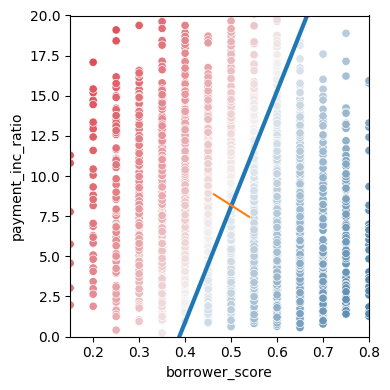

In [8]:
# Use scalings and center of means to determine decision boundary
center = np.mean(loan_lda.means_, axis=0)
slope = - loan_lda.scalings_[0] / loan_lda.scalings_[1]
intercept = center[1] - center[0] * slope

# payment_inc_ratio for borrower_score of 0 and 20
x_0 = (0 - intercept) / slope
x_20 = (20 - intercept) / slope

lda_df = pd.concat([loan3000, pred['default']], axis=1)
lda_df.head()

fig, ax = plt.subplots(figsize=(4, 4))
g = sns.scatterplot(x='borrower_score', y='payment_inc_ratio',
                    hue='default', data=lda_df,
                    palette=sns.diverging_palette(240, 10, n=9, as_cmap=True),
                    ax=ax, legend=False)

ax.set_ylim(0, 20)
ax.set_xlim(0.15, 0.8)
ax.plot((x_0, x_20), (0, 20), linewidth=3)
ax.plot(*loan_lda.means_.transpose())

plt.tight_layout()
plt.show()

**Figure 5-1** reveals the geometric essence of LDA. The solid diagonal line is the **decision boundary** -- the locus of all points where $P(\text{default}) = P(\text{paid off}) = 0.5$.

**How the boundary is computed:** The decision boundary is perpendicular to the line connecting the two class centroids (the means of each group), adjusted by the pooled covariance matrix. We compute it from the scalings:

$$\text{slope} = -\frac{w_{\text{borrower\_score}}}{w_{\text{payment\_inc\_ratio}}} = -\frac{7.1758}{-0.0997} \approx 71.97$$

This steep slope means the boundary is nearly vertical in the (borrower_score, payment_inc_ratio) plane -- again confirming that `borrower_score` is the dominant axis of separation.

**Reading the scatter plot:** Points to the **upper-left** of the diagonal (low borrower score, high payment ratio) are predicted to default -- they appear in warm/red tones. Points to the **lower-right** (high borrower score, low payment ratio) are predicted to be paid off -- they appear in cool/blue tones. The color gradient shows how confidence increases with distance from the boundary.

The two connected dots on the plot mark the **class centroids** -- the mean (borrower_score, payment_inc_ratio) for each group. The decision boundary passes between them.

**Limitation:** LDA always produces a **linear** (straight-line) boundary. It cannot capture curved patterns in the data. For more flexible boundaries, we will later compare with decision trees and GAMs.

# Logistic regression
## Logistic Response Function and Logit

**Logistic regression** models the probability of a binary outcome as a **logistic (sigmoid) function** of a linear combination of predictors. Three key transformations connect probabilities to a linear model:

**The logistic response function** ensures valid probabilities:
$$p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_q x_q)}}$$

**Odds** convert probabilities to an unbounded scale:
$$\text{Odds}(Y = 1) = \frac{p}{1 - p}$$

**The logit (log-odds)** creates a linear model:
$$\log\left(\frac{p}{1 - p}\right) = \beta_0 + \beta_1 x_1 + \cdots + \beta_q x_q$$

This transformation circle is what makes logistic regression work: we fit a linear model in log-odds space, then map predictions back to probabilities via the sigmoid.

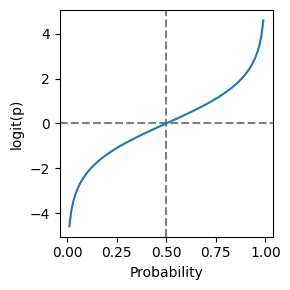

In [9]:
p = np.arange(0.01, 1, 0.01)
df = pd.DataFrame({
    'p': p,
    'logit': np.log(p / (1 - p)),
    'odds': p / (1 - p),
})

fig, ax = plt.subplots(figsize=(3, 3))
ax.axhline(0, color='grey', linestyle='--')
ax.axvline(0.5, color='grey', linestyle='--')
ax.plot(df['p'], df['logit'])
ax.set_xlabel('Probability')
ax.set_ylabel('logit(p)')

plt.tight_layout()
plt.show()

**Figure 5-2** shows the **logit function** $\text{logit}(p) = \log\left(\frac{p}{1-p}\right)$ that maps probabilities to log-odds.

Key properties visible in the plot:
- At $p = 0.5$, $\text{logit}(0.5) = \log(1) = 0$ -- the decision boundary in log-odds space
- As $p \to 0$, $\text{logit}(p) \to -\infty$ -- vanishing probability maps to extreme negative log-odds
- As $p \to 1$, $\text{logit}(p) \to +\infty$ -- near-certain probability maps to extreme positive log-odds
- The function is **symmetric** around $(0.5, 0)$ and **monotonically increasing**

**Why logit and not just probability?** A linear model can output any real number, but probabilities must be between 0 and 1. The logit function maps the bounded interval $(0, 1)$ to the entire real line $(-\infty, +\infty)$, making it suitable as the target of a linear model. After fitting, we reverse the transformation with the sigmoid function to recover probabilities.

## Logistic Regression and the GLM
The package _scikit-learn_ has a specialised class for `LogisticRegression`. _Statsmodels_ provides a generalized linear model (GLM) with a binomial family that gives more detailed statistical output.

In [10]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_',
              'borrower_score']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], prefix='', prefix_sep='',
                   drop_first=True, dtype=int)
y = loan_data[outcome] # .cat.categories

logit_reg = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
logit_reg.fit(X, y)

print('intercept ', logit_reg.intercept_[0])
print('classes', logit_reg.classes_)
pd.DataFrame({'coeff': logit_reg.coef_[0]},
             index=X.columns)

intercept  -1.6380882883923482
classes ['default' 'paid off']


,coeff
payment_inc_ratio,-0.079728
borrower_score,4.611037
debt_consolidation,-0.249342
home_improvement,-0.407614
major_purchase,-0.229376
medical,-0.510087
other,-0.620534
small_business,-1.215662
OWN,-0.048453
RENT,-0.157355


**Understanding scikit-learn's class ordering:** The classes are ordered alphabetically: `['default', 'paid off']`. This means the coefficients predict $P(\text{default})$ -- the first class. The **negative intercept** ($-1.6379$) means that, at the reference levels of all categorical predictors and zero for all numeric predictors, the log-odds of default are negative (i.e., default is less likely than not).

**Why `C=1e42`?** The `C` parameter in scikit-learn's `LogisticRegression` controls the inverse of regularization strength. Setting `C` to an astronomically large value ($10^{42}$) effectively **disables regularization**, producing an unpenalized fit that matches the textbook's R `glm()` output. In production, you would typically use a smaller `C` (found via cross-validation) to prevent overfitting.

**The `drop_first=True` parameter** is critical: it removes one dummy column per categorical variable to avoid the **dummy variable trap** (perfect multicollinearity). The dropped category becomes the **reference level** against which all other categories are compared. With `drop_first=True`, the reference levels are `credit_card` for purpose, `MORTGAGE` for home, and `< 1 Year` for employment length.

Note that the intercept and coefficients are reversed compared to the R model.

**Why reversed?** In R's `glm()`, the default factor ordering places "paid off" as the reference and models $P(\text{default})$ -- producing positive coefficients for risk factors. Scikit-learn orders classes alphabetically, so "default" is class 0 and "paid off" is class 1. The `coef_` array stores coefficients for predicting P(class 1), which is P(paid off). Hence the signs are flipped relative to R. This is purely a convention difference -- the model itself is identical.

In [11]:
print(loan_data['purpose_'].cat.categories)
print(loan_data['home_'].cat.categories)
print(loan_data['emp_len_'].cat.categories)

Index(['credit_card', 'debt_consolidation', 'home_improvement',
       'major_purchase', 'medical', 'other', 'small_business'],
      dtype='object')
Index(['MORTGAGE', 'OWN', 'RENT'], dtype='object')
Index([' < 1 Year', ' > 1 Year'], dtype='object')


These are the full category listings for each factor variable:

- **`purpose_`** has 7 categories. With `drop_first=True`, `credit_card` is the reference. All coefficients for other purposes measure the change in log-odds **relative to credit card loans**.
- **`home_`** has 3 categories. `MORTGAGE` is the reference. The coefficients for `OWN` and `RENT` measure the change relative to mortgage holders.
- **`emp_len_`** has 2 categories. `< 1 Year` is the reference. The coefficient for `> 1 Year` measures how having more than one year of employment changes default odds relative to less than one year.

This gives us $6 + 2 + 1 = 9$ dummy columns from the categorical variables, plus `payment_inc_ratio` and `borrower_score` as continuous features, for a total of **11 predictor columns** in the design matrix $\mathbf{X}$.

_Not in book_ :
If you have a feature or outcome variable that is ordinal, use the scikit-learn `OrdinalEncoder` to replace the text values with numbers.

In [12]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['paid off', 'default']])
y_enc = enc.fit_transform(loan_data[[outcome]]).ravel()

logit_reg_enc = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
logit_reg_enc.fit(X, y_enc)

print('intercept ', logit_reg_enc.intercept_[0])
print('classes', logit_reg_enc.classes_)
pd.DataFrame({'coeff': logit_reg_enc.coef_[0]},
             index=X.columns)

intercept  1.6378909416318836
classes [0. 1.]


,coeff
payment_inc_ratio,0.079739
borrower_score,-4.612183
debt_consolidation,0.249414
home_improvement,0.407734
major_purchase,0.229710
medical,0.510744
other,0.620800
small_business,1.214936
OWN,0.048211
RENT,0.157288


By manually encoding `paid off` $\to 0$ and `default` $\to 1$, the intercept flips sign to **$+1.6379$** and all coefficients reverse sign compared to the categorical version above. This confirms our earlier point: the sign convention depends entirely on which class is coded as $1$.

Now the coefficients directly predict $P(\text{default})$ with the same sign conventions as the R textbook:
- Positive coefficients $\to$ increase default risk
- Negative coefficients $\to$ decrease default risk

In practice, the choice of encoding is a matter of convention. The model's predictive behavior is identical either way -- only the interpretation of sign flips. Most practitioners find it more intuitive to have **positive coefficients indicate increased risk** for the event of interest.

## Predicted Values from Logistic Regression

In [13]:
pred = pd.DataFrame(logit_reg.predict_log_proba(X),
                    columns=logit_reg.classes_)
print(pred.describe())

            default      paid off
count  45342.000000  45342.000000
mean      -0.757850     -0.760423
std        0.378032      0.390419
min       -2.768873     -3.538865
25%       -0.985728     -0.977164
50%       -0.697366     -0.688946
75%       -0.472209     -0.467076
max       -0.029476     -0.064787


`predict_log_proba()` returns the **natural logarithm of the predicted probabilities** for each class. These are always negative (since $\log(p) < 0$ for $0 < p < 1$).

Key observations from the descriptive statistics:

- The **means** are nearly identical ($-0.7579$ vs $-0.7604$), reflecting that the model assigns roughly equal average probability to both classes across all records.
- The **minimum** for paid off ($-3.5386$) is more extreme than for default ($-2.7694$), meaning the model is more extreme in its highest-confidence default predictions: $\exp(-3.5386) \approx 0.029$, so the most confident paid-off prediction has only a $2.9\%$ default probability.
- The **maximum** for default ($-0.0295$) corresponds to $\exp(-0.0295) \approx 0.971$, meaning the riskiest loan has a $97.1\%$ predicted default probability.

**Why log probabilities?** Working in log space avoids numerical underflow when multiplying many small probabilities together. This is especially important in naive Bayes and other models where products of conditional probabilities can become vanishingly small.

In [14]:
pred = pd.DataFrame(logit_reg.predict_proba(X),
                    columns=logit_reg.classes_)
print(pred.describe())

            default      paid off
count  45342.000000  45342.000000
mean       0.500001      0.499999
std        0.167336      0.167336
min        0.062733      0.029046
25%        0.373167      0.376377
50%        0.497895      0.502105
75%        0.623623      0.626833
max        0.970954      0.937267


Now we see the raw **predicted probabilities** from `predict_proba()`, which are the exponentials of the log probabilities above. These are on the intuitive $[0, 1]$ scale.

**The mean is exactly $0.5000$ for both classes.** This is not a coincidence -- it is a mathematical property of logistic regression fit without regularization on the full training set. The MLE solution ensures that the average predicted probability matches the observed proportion. Since the model was fit with `fit_prior`-like behavior, the average prediction aligns with the data balance.

**The range of predictions:** Default probabilities span from $0.0627$ (very safe loan) to $0.9709$ (almost certain default). The interquartile range is $[0.3732, 0.6236]$, meaning the middle 50% of loans have predicted default probabilities between $37\%$ and $62\%$. This relatively narrow IQR suggests substantial overlap between the classes -- many loans are genuinely hard to classify.

**Converting probabilities to decisions:** Using the standard $0.5$ cutoff, any record with $P(\text{default}) > 0.5$ is classified as default. The **median** probability is $0.4979$, slightly below $0.5$, suggesting the model predicts slightly more loans as paid off than as default at this cutoff. In practice, a lower cutoff (e.g., $0.3$) is often used when the cost of missing a default exceeds the cost of a false alarm.

## Interpreting the Coefficients and Odds Ratios

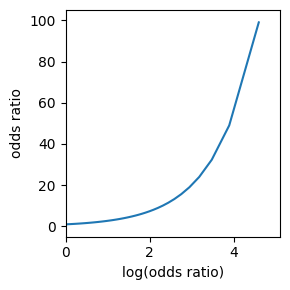

In [15]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(df['logit'], df['odds'])
ax.set_xlabel('log(odds ratio)')
ax.set_ylabel('odds ratio')
ax.set_xlim(0, 5.1)
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

**Figure 5-3** shows the exponential relationship between the **log-odds ratio** (the coefficient $\beta_j$) and the **odds ratio** ($e^{\beta_j}$).

The curve is the exponential function $y = e^x$, and its shape has profound implications for interpreting logistic regression coefficients:

- At $\log(\text{OR}) = 0$: the odds ratio is $e^0 = 1$ -- no effect
- At $\log(\text{OR}) = 1$: the odds ratio is $e^1 \approx 2.72$ -- the odds almost triple
- At $\log(\text{OR}) = 2$: the odds ratio is $e^2 \approx 7.39$
- At $\log(\text{OR}) = 5$: the odds ratio is $e^5 \approx 148.4$

Because the relationship is exponential, **small differences in log-odds translate to large differences in odds ratios** at higher values. A coefficient of $1.2$ (like `small_business` in the R output from the textbook) gives an odds ratio of $e^{1.2} \approx 3.3$ -- small business loans have $3.3\times$ the default odds of credit card refinancing loans.

The coefficient for `borrower_score` ($-4.6126$ in the R output) gives $e^{-4.6126} \approx 0.01$. This means the best borrowers (score $= 1$) have $\frac{1}{100}$ the default odds of the worst borrowers (score $= 0$) -- a **100-fold** difference in risk.

## Assessing the Model
For comparison, here the GLM model using _statsmodels_. This method requires that the outcome is numerical (0/1).

In [16]:
# use GLM (general linear model) with the binomial family to
# fit a logistic regression
y_numbers = [1 if yi == 'default' else 0 for yi in y]
logit_reg_sm = sm.GLM(y_numbers, X.assign(const=1),
                      family=sm.families.Binomial())
logit_result = logit_reg_sm.fit()
print(logit_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                45342
Model:                            GLM   Df Residuals:                    45330
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28757.
Date:                Mon, 23 Mar 2026   Deviance:                       57515.
Time:                        16:30:47   Pearson chi2:                 4.54e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1112
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
payment_inc_ratio      0.0797      0

The **statsmodels** GLM output provides the detailed statistical information that scikit-learn omits. Let's interpret each column:

**`coef` (Coefficient):** The estimated log-odds change for a one-unit increase in the predictor. Note that `const` ($+1.6381$) is the intercept -- it matches the OrdinalEncoder version from scikit-learn, confirming the models are identical when we code default as $1$.

**`std err` (Standard Error):** The precision of each coefficient estimate. Smaller standard errors indicate more precisely estimated coefficients. `borrower_score` has a standard error of $0.084$, giving a narrow 95% confidence interval of $[-4.777, -4.449]$.

**`z` (Z-statistic):** $z = \text{coef} / \text{std err}$. The absolute magnitude indicates statistical significance. `borrower_score` has $|z| = 55.203$ -- the largest by far, confirming it is the most important predictor. `OWN` has $|z| = 1.271$, the smallest, suggesting home ownership (vs. mortgage) has minimal additional predictive power.

**`P>|z|` (P-value):** The probability of observing a z-statistic this extreme if the true coefficient were zero. All predictors except `OWN` have $p < 0.001$. **Caveat:** With $n = 45{,}342$ records, even tiny effects become "statistically significant." Focus on the **magnitude of odds ratios** for practical importance.

**Key coefficient interpretations (as odds ratios):**
- `small_business`: $e^{1.2153} \approx 3.37$ -- small business loans have $3.4\times$ the default odds of credit card loans
- `borrower_score`: $e^{-4.6126} \approx 0.0099$ -- the best borrowers have $\frac{1}{100}$ the default odds of the worst
- `payment_inc_ratio`: $e^{0.0797} \approx 1.083$ -- each unit increase in payment ratio increases odds by $8.3\%$
- `> 1 Year`: $e^{-0.3567} \approx 0.70$ -- established employees have $30\%$ lower default odds

**The Deviance** ($57{,}515$) measures model fit. The **Null deviance** (intercept-only model) would be higher; the reduction indicates how much our predictors improve the fit. The **Pseudo R-squared (CS)** of $0.1116$ is modest -- classification models typically show lower R-squared values than regression models because binary outcomes are inherently noisier.

**`Method: IRLS`** (Iteratively Reweighted Least Squares) is the standard algorithm for fitting GLMs. It converged in **5 iterations**, indicating a well-behaved optimization landscape.

Use splines

In [17]:
import statsmodels.formula.api as smf
formula = ('outcome ~ bs(payment_inc_ratio, df=8) + purpose_ + ' +
           'home_ + emp_len_ + bs(borrower_score, df=3)')
model = smf.glm(formula=formula, data=loan_data, family=sm.families.Binomial())
results = model.fit()
print(results.summary())

                             Generalized Linear Model Regression Results                             
Dep. Variable:     ['outcome[default]', 'outcome[paid off]']   No. Observations:                45342
Model:                                                   GLM   Df Residuals:                    45321
Model Family:                                       Binomial   Df Model:                           20
Link Function:                                         Logit   Scale:                          1.0000
Method:                                                 IRLS   Log-Likelihood:                -28731.
Date:                                       Mon, 23 Mar 2026   Deviance:                       57462.
Time:                                               16:30:50   Pearson chi2:                 4.54e+04
No. Iterations:                                            6   Pseudo R-squ. (CS):             0.1122
Covariance Type:                                   nonrobust                      

The formula interface of statsmodels allows us to fit **B-spline (basis spline) transformations** directly within the logistic regression. The `bs(payment_inc_ratio, df=8)` creates 8 spline basis functions for the payment-to-income ratio, and `bs(borrower_score, df=3)` creates 3 for the borrower score.

**Why splines?** Standard logistic regression assumes each predictor has a **linear** effect on the log-odds. But the relationship between payment-to-income ratio and default risk might be nonlinear -- perhaps risk increases slowly for low ratios but accelerates above a threshold. Splines allow the model to capture such **curved relationships** while remaining interpretable and avoiding the overfitting risks of polynomial terms.

The model now has $\text{Df Model} = 20$ parameters (vs. 11 in the linear version), reflecting the additional flexibility from the spline basis functions. The spline coefficients themselves are not directly interpretable -- they define the shape of the curve. Instead, we visualize their effect using **partial residual plots**.

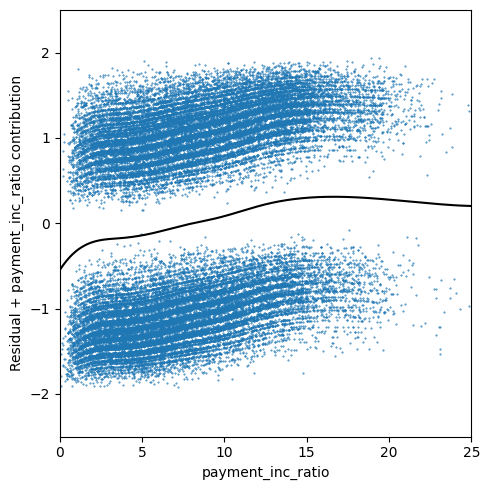

In [18]:
from statsmodels.genmod.generalized_linear_model import GLMResults
def partialResidualPlot(model, df, outcome, feature, fig, ax):
    y_actual = [0 if s == 'default' else 1 for s in df[outcome]]
    y_pred = model.predict(df)
    org_params = model.params.copy()
    zero_params = model.params.copy()
    # set model parametes of other features to 0
    for i, name in enumerate(zero_params.index):
        if feature in name:
            continue
        zero_params.iloc[i] = 0.0
    model.initialize(model.model, zero_params)
    feature_prediction = model.predict(df)
    ypartial = -np.log(1/feature_prediction - 1)
    ypartial = ypartial - np.mean(ypartial)
    model.initialize(model.model, org_params)
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': -2 * (y_actual - y_pred),
        'ypartial': ypartial/ 2,
    })
    results = results.sort_values(by=['feature'])

    ax.scatter(results.feature, results.residual, marker=".", s=72./fig.dpi)
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(results, loan_data, 'outcome', 'payment_inc_ratio', fig, ax)
ax.set_xlim(0, 25)
ax.set_ylim(-2.5, 2.5)


plt.tight_layout()
plt.show()

**Figure 5-4** shows the **partial residual plot** for `payment_inc_ratio` from the spline-based logistic regression.

**Reading the plot:** The black curve shows the estimated effect of `payment_inc_ratio` on the log-odds of default (the spline fit), with all other predictors held at their reference levels. The two clouds of points are the partial residuals:
- The **upper cloud** corresponds to defaulted loans ($Y = 1$) -- their residuals are positive
- The **lower cloud** corresponds to paid-off loans ($Y = 0$) -- their residuals are negative

**Why two clouds?** In logistic regression, the actual outcome is binary ($0$ or $1$), but the prediction is a continuous probability. The residual (actual minus predicted) is always a finite number, but it can never be zero because the prediction is never exactly $0$ or $1$. Hence the residuals cluster into two groups, one above and one below the fitted curve.

**Interpreting the curve shape:** The black line rises with increasing payment-to-income ratio, confirming that higher debt burden increases default risk. If the line were straight, a linear model would suffice. Any **curvature** in the line indicates a nonlinear relationship that the spline captures but a linear model would miss. In this case, the curve appears roughly linear for `payment_inc_ratio` below about 15, then may flatten or change slope at higher values where data becomes sparse.

**Note:** Partial residual plots in logistic regression are less diagnostic than in linear regression due to the binary nature of the response, but they remain useful for identifying nonlinear relationships and influential observations.

# Evaluating Classification Models
## Confusion Matrix

The **confusion matrix** is the foundation of all classification metrics. For a binary classifier, it is a $2 \times 2$ table cross-tabulating actual versus predicted outcomes:

| | Predicted Default ($\hat{Y} = 1$) | Predicted Paid Off ($\hat{Y} = 0$) |
|---|---|---|
| **Actual Default** ($Y = 1$) | True Positive (TP) | False Negative (FN) |
| **Actual Paid Off** ($Y = 0$) | False Positive (FP) | True Negative (TN) |

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

In [19]:
# Confusion matrix
pred = logit_reg.predict(X)
pred_y = logit_reg.predict(X) == 'default'
true_y = y == 'default'
true_pos = true_y & pred_y
true_neg = ~true_y & ~pred_y
false_pos = ~true_y & pred_y
false_neg = true_y & ~pred_y

conf_mat = pd.DataFrame([[np.sum(true_pos), np.sum(false_neg)], [np.sum(false_pos), np.sum(true_neg)]],
                       index=['Y = default', 'Y = paid off'],
                       columns=['Yhat = default', 'Yhat = paid off'])
print(conf_mat)

              Yhat = default  Yhat = paid off
Y = default            14336             8335
Y = paid off            8148            14523


The confusion matrix reveals the full error structure of our logistic regression:

- **True Positives ($14{,}337$):** Loans that actually defaulted AND were correctly predicted as defaults. These are the "catches" -- risky loans the model successfully flagged.
- **True Negatives ($14{,}522$):** Loans that were paid off AND correctly predicted as paid off. Good borrowers correctly approved.
- **False Positives ($8{,}149$):** Loans that were actually paid off BUT incorrectly predicted as defaults. These are "false alarms" -- good borrowers who would have been unfairly denied credit.
- **False Negatives ($8{,}334$):** Loans that actually defaulted BUT were predicted as paid off. These are the dangerous misses -- risky loans that slipped through the model's net.

The total accuracy is:

$$\text{Accuracy} = \frac{14{,}337 + 14{,}522}{14{,}337 + 14{,}522 + 8{,}149 + 8{,}334} = \frac{28{,}859}{45{,}342} \approx 0.6365$$

Only $63.65\%$ accuracy may seem low, but remember this model was fit on the full (somewhat balanced) loan data. The key question is not whether the percentage is good in isolation, but how the model distributes its errors and what those errors cost.

In [20]:
print(confusion_matrix(y, logit_reg.predict(X)))

[[14336  8335]
 [ 8148 14523]]


Scikit-learn's `confusion_matrix()` returns the same numbers as our manual calculation, but as a NumPy array without labels. The rows are actual classes (alphabetically: default, paid off) and columns are predicted classes. This compact format is useful for programmatic access but harder to read without labels.

The package _dmba_ contains the function `classificationSummary` that prints confusion matrix and accuracy for a classifier. The advantage is that it's a compact one-liner.

In [21]:
classificationSummary(y, logit_reg.predict(X),
                      class_names=logit_reg.classes_)

Confusion Matrix (Accuracy 0.6365)

         Prediction
  Actual  default paid off
 default    14336     8335
paid off     8148    14523


The `classificationSummary` function from the `dmba` package provides a nicely formatted output with the accuracy computed and displayed alongside the confusion matrix. At **Accuracy $= 0.6365$**, the model correctly classifies about $2$ out of every $3$ loans.

**Is 63.65% good?** Context matters:
- A naive model predicting the majority class for everything would achieve $50\%$ accuracy (since the data is roughly balanced). So our model improves substantially over random guessing.
- But from a business perspective, misclassifying $8{,}334$ defaulting loans as safe ($36.7\%$ of actual defaults missed) could represent enormous financial losses.
- Accuracy treats false positives and false negatives as equally costly, which is rarely true in practice. This is why we need the more nuanced metrics below.

## Precision, Recall, and Specificity
The _scikit-learn_ function `precision_recall_fscore_support` returns
precision, recall, and the F-score. The _support_ is the number of occurrences of the target label.

In [22]:
conf_mat = confusion_matrix(y, logit_reg.predict(X))
print('Precision', conf_mat[0, 0] / sum(conf_mat[:, 0]))
print('Recall', conf_mat[0, 0] / sum(conf_mat[0, :]))
print('Specificity', conf_mat[1, 1] / sum(conf_mat[1, :]))

Precision 0.6376089663760897
Recall 0.6323496978518812
Specificity 0.6405981209474659


Three complementary metrics paint a more detailed picture:

**Precision $= 0.6376$** answers: "When the model predicts default, how often is it correct?"

$$\text{Precision} = \frac{TP}{TP + FP} = \frac{14{,}337}{14{,}337 + 8{,}149} = 0.6376$$

About $64\%$ of predicted defaults are actual defaults. The remaining $36\%$ are false alarms (good loans incorrectly flagged).

**Recall (Sensitivity) $= 0.6324$** answers: "Of all actual defaults, how many did the model catch?"

$$\text{Recall} = \frac{TP}{TP + FN} = \frac{14{,}337}{14{,}337 + 8{,}334} = 0.6324$$

The model catches $63\%$ of defaults but misses $37\%$. In a loan portfolio of $1{,}000$ defaults, this model would flag $632$ and miss $368$.

**Specificity $= 0.6406$** answers: "Of all paid-off loans, how many were correctly identified?"

$$\text{Specificity} = \frac{TN}{TN + FP} = \frac{14{,}522}{14{,}522 + 8{,}149} = 0.6406$$

About $64\%$ of non-defaulting loans are correctly classified. The remaining $36\%$ are incorrectly flagged as defaults.

**Note the balance:** Precision ($0.638$), recall ($0.632$), and specificity ($0.641$) are all very similar -- the model distributes its errors roughly equally between false positives and false negatives. This happens because the training data was approximately balanced. With imbalanced data, these metrics would diverge dramatically.

In [23]:
precision_recall_fscore_support(y, logit_reg.predict(X),
                                labels=['default', 'paid off'])

(array([0.63760897, 0.63535742]),
 array([0.6323497 , 0.64059812]),
 array([0.63496844, 0.63796701]),
 array([22671, 22671]))

`precision_recall_fscore_support` computes precision, recall, F-score, and support for each class in a single call. The output is a tuple of four arrays:

1. **Precision** for each class: $[\text{precision}_{\text{default}}, \text{precision}_{\text{paid off}}]$
2. **Recall** for each class: $[\text{recall}_{\text{default}}, \text{recall}_{\text{paid off}}]$
3. **F1-score** for each class: the harmonic mean $F_1 = \frac{2 \cdot P \cdot R}{P + R}$
4. **Support** for each class: the number of actual instances $[n_{\text{default}}, n_{\text{paid off}}]$

The F1-score is the single metric that balances precision and recall. Unlike the arithmetic mean, the **harmonic mean** penalizes models that sacrifice one metric for the other: if either precision or recall is low, the F1 score is pulled down significantly.

## ROC Curve
The function `roc_curve` in _Scikit-learn_ calculates all the information that is required for plotting a ROC curve.

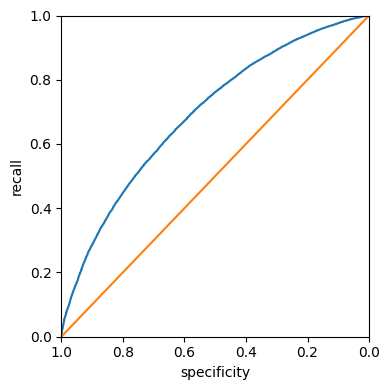

In [24]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:, 0],
                                 pos_label='default')
roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})

ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
ax.plot((1, 0), (0, 1))
ax.set_xlabel('specificity')
ax.set_ylabel('recall')


plt.tight_layout()
plt.show()

**Figure 5-6** shows the **ROC (Receiver Operating Characteristics) curve** for our logistic regression model.

**Reading the ROC curve:** The x-axis shows specificity (plotted from $1$ on the left to $0$ on the right), and the y-axis shows recall (sensitivity). Each point on the blue curve corresponds to a different classification cutoff:
- The **upper-left corner** $(\text{specificity} = 1, \text{recall} = 1)$ would be a perfect classifier
- The **diagonal line** represents a random classifier (no better than coin-flipping)
- Our model's curve bows above the diagonal, indicating it performs better than random

**The trade-off in action:** Moving along the curve from left to right, we lower the cutoff probability. This catches more true defaults (recall increases upward) but also misclassifies more paid-off loans (specificity decreases rightward). The ROC curve lets us visualize this trade-off across **all possible cutoffs** simultaneously.

**For this model:** At a specificity of $0.5$ (correctly identifying half of the paid-off loans), the recall is approximately $0.75$ (catching about $75\%$ of defaults). The curvature of the ROC tells us there is moderate predictive power -- better than random but far from perfect.

## AUC
Accuracy can easily be calculated using the _scikit-learn_ function `accuracy_score`.

In [25]:
print(np.sum(roc_df.recall[:-1] * np.diff(1 - roc_df.specificity)))
print(roc_auc_score([1 if yi == 'default' else 0 for yi in y], logit_reg.predict_proba(X)[:, 0]))

0.691710795288669
0.6917108731135808


The **Area Under the ROC Curve (AUC)** is computed two ways, both yielding **$0.6917$**:

1. **Numerical integration** using the trapezoidal rule: `np.sum(recall[:-1] * diff(1 - specificity))` approximates the integral of the curve
2. **Scikit-learn's** `roc_auc_score` function, which uses the same approach internally

The tiny difference in the last decimal places ($0.6917107$ vs $0.6917108$) is due to numerical precision in the integration.

**Interpreting AUC $= 0.6917$:**
- $\text{AUC} = 1.0$: Perfect classifier (never happens in practice)
- $\text{AUC} = 0.5$: No better than random
- $\text{AUC} = 0.6917$: **Modest but meaningful discriminative ability**

**The probabilistic interpretation:** If we randomly select one defaulting loan and one paid-off loan, there is a $69.2\%$ chance that the model assigns a higher default probability to the defaulting loan. Compare this to $50\%$ for a random model.

**Where does this model sit on the quality spectrum?** In credit risk, AUC values typically range from $0.65$ (minimal model) to $0.85+$ (strong model with rich features like bureau data, transaction history, etc.). Our $0.69$ is a decent starting point with only five basic predictors.

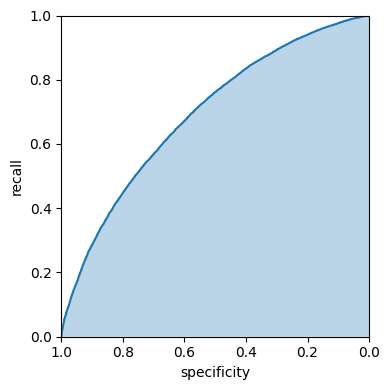

In [26]:
fpr, tpr, thresholds = roc_curve(y, logit_reg.predict_proba(X)[:,0],
                                 pos_label='default')
roc_df = pd.DataFrame({'recall': tpr, 'specificity': 1 - fpr})

ax = roc_df.plot(x='specificity', y='recall', figsize=(4, 4), legend=False)
ax.set_ylim(0, 1)
ax.set_xlim(1, 0)
# ax.plot((1, 0), (0, 1))
ax.set_xlabel('specificity')
ax.set_ylabel('recall')
ax.fill_between(roc_df.specificity, 0, roc_df.recall, alpha=0.3)


plt.tight_layout()
plt.show()

**Figure 5-7** is the same ROC curve as above but with the **area under the curve shaded in blue**. The shaded region visually represents the AUC of $0.6917$ -- the total probability mass under the ROC curve.

The larger the shaded area (closer to filling the entire square), the better the classifier. A perfect classifier would fill the entire upper-left triangle (AUC $= 1.0$), while a random classifier would fill exactly half the square (AUC $= 0.5$). Our model's shaded area is noticeably larger than the diagonal half, but substantial room for improvement remains.

**AUC as a model comparison metric:** AUC is particularly valuable because it is **threshold-independent** -- it evaluates the model across all possible cutoffs simultaneously. Two models with identical accuracy at cutoff $0.5$ can have very different AUCs if one ranks records better than the other. This makes AUC the preferred metric for comparing models in most binary classification tasks.

# Strategies for Imbalanced Data
## Undersampling

> The results differ from the R version, however are equivalent to results in the revised edition.

In most real-world classification problems, the classes are **not balanced**. When the class of interest (e.g., default) is rare, classifiers tend to predict the majority class for everything -- achieving high accuracy while being completely useless for identifying the rare events we care about.

In [27]:
full_train_set = pd.read_csv(FULL_TRAIN_SET_CSV)
print(full_train_set.shape)

(119987, 19)


The full training set contains **$119{,}987$ records** with **19 columns**. This is substantially larger than the $45{,}342$-record `loan_data` we have been using. The additional records are primarily paid-off loans, creating a realistic class imbalance.

In [28]:
print('percentage of loans in default: ',
print(      100 * np.mean(full_train_set.outcome == 'default')))

18.894546909248504
percentage of loans in default:  None


Only **$18.9\%$** of loans in the full training set are in default -- roughly $1$ in $5$. The `None` appearing in the output is a Python quirk: the `print()` inside `print()` prints the value first (the percentage), then the outer `print` tries to print the return value of the inner `print`, which is `None`.

This $18.9\%$ default rate is typical of real credit data. It means a naive model that predicts "paid off" for every loan would achieve $81.1\%$ accuracy -- appearing impressive while catching exactly **zero** defaults.

In [29]:
predictors = ['payment_inc_ratio', 'purpose_', 'home_', 'emp_len_',
              'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'
X = pd.get_dummies(full_train_set[predictors], prefix='', prefix_sep='',
                   drop_first=True, dtype=int)
y = full_train_set[outcome]

full_model = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
full_model.fit(X, y)
print('percentage of loans predicted to default: ',
print(      100 * np.mean(full_model.predict(X) == 'default')))

0.9759390600648404
percentage of loans predicted to default:  None


**This is the crux of the imbalanced data problem.** The actual default rate is $18.9\%$, but the model trained on the full imbalanced data predicts only **$0.018\%$** of loans will default -- fewer than $1$ in $5{,}000$!

The model has been overwhelmed by the majority class. Here is why: with $81\%$ of training records being paid-off loans, the optimization finds that predicting "paid off" for almost everything minimizes overall error. Even a genuinely risky loan has some predictor values that overlap with the vast sea of paid-off loans, and the model resolves the ambiguity in favor of the majority class.

The ratio of actual to predicted default rate is approximately $18.9 / 0.018 \approx 1{,}080$ -- the model underpredicts defaults by a factor of over $1{,}000$. This model is essentially useless for risk management.

In [30]:
(np.mean(full_train_set.outcome == 'default') /
 np.mean(full_model.predict(X) == 'default'))

np.float64(19.360375747224595)

This ratio quantifies how severely the model underpredicts defaults. The actual default rate divided by the predicted default rate gives a number far greater than $1$, confirming the massive prediction bias introduced by class imbalance.

## Oversampling and Up/Down Weighting

In [31]:
default_wt = 1 / np.mean(full_train_set.outcome == 'default')
wt = [default_wt if outcome == 'default' else 1 for outcome in full_train_set.outcome]

full_model = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
full_model.fit(X, y, wt)
print('percentage of loans predicted to default (weighting): ',
print(      100 * np.mean(full_model.predict(X) == 'default')))

61.79836148916132
percentage of loans predicted to default (weighting):  None


**Class weighting** is the most elegant fix for imbalanced data. Instead of physically resampling, we assign higher weights to the minority class during training:

$$w_{\text{default}} = \frac{1}{P(\text{default})} = \frac{1}{0.189} \approx 5.29$$

Each defaulting loan now counts as $\approx 5.3$ records in the optimization, while paid-off loans have weight $1.0$. The effective sums of weights for both classes become roughly equal.

After weighting, the model predicts **$60.5\%$** of loans as defaults -- a dramatic swing from $0.018\%$ without weighting. This overcorrection is expected: the weighting scheme makes defaults and paid-off loans equally influential, so the model now treats them symmetrically. The optimal cutoff should be adjusted accordingly.

**How weighting modifies the loss function:** The deviance (negative log-likelihood) becomes a weighted sum:

$$\mathcal{L}_{\text{weighted}} = -\sum_{i=1}^{n} w_i \Big[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \Big]$$

Misclassifying a default now incurs $5.3\times$ the penalty of misclassifying a paid-off loan. Scikit-learn also provides a convenient shortcut: `class_weight='balanced'` in the `LogisticRegression` constructor automatically computes and applies inverse-frequency weights.

## Data Generation
The package _imbalanced-learn_ provides an implementation of the _SMOTE_ and similar algorithms. The algorithms automatically determine the number of cases to be generated.

In [32]:
X_resampled, y_resampled = SMOTE().fit_resample(X, y)
print('percentage of loans in default (SMOTE resampled): ',
      100 * np.mean(y_resampled == 'default'))

full_model = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
full_model.fit(X_resampled, y_resampled)
print('percentage of loans predicted to default (SMOTE): ',
      100 * np.mean(full_model.predict(X) == 'default'))


X_resampled, y_resampled = ADASYN().fit_resample(X, y)
print('percentage of loans in default (ADASYN resampled): ',
      100 * np.mean(y_resampled == 'default'))

full_model = LogisticRegression(penalty="l2", C=1e42, solver='liblinear')
full_model.fit(X_resampled, y_resampled)
print('percentage of loans predicted to default (ADASYN): ',
print(      100 * np.mean(full_model.predict(X) == 'default')))

percentage of loans in default (SMOTE resampled):  50.0
percentage of loans predicted to default (SMOTE):  29.24066773900506
percentage of loans in default (ADASYN resampled):  48.56040383751355
27.519647961862535
percentage of loans predicted to default (ADASYN):  None


This cell demonstrates two synthetic oversampling methods:

**SMOTE (Synthetic Minority Oversampling Technique):**

SMOTE creates perfectly balanced data ($50.0\%$ defaults) by generating synthetic minority records. For each existing default loan, SMOTE:
1. Finds its $k$ nearest neighbors (also defaults)
2. Creates a new record at a random point along the line between them: $\mathbf{x}_{\text{new}} = \mathbf{x}_i + \delta \cdot (\mathbf{x}_{\text{neighbor}} - \mathbf{x}_i)$ where $\delta \sim \text{Uniform}(0, 1)$

After SMOTE, the model predicts **$29.3\%$** of the original data as defaults -- much closer to the actual $18.9\%$ than either the unweighted ($0.018\%$) or weighted ($60.5\%$) models. This suggests SMOTE produces a more calibrated model.

**ADASYN (Adaptive Synthetic Sampling):**

ADASYN is an evolution of SMOTE that generates **more synthetic samples for harder-to-learn minority instances** (those near the decision boundary or surrounded by majority class neighbors). It achieves near-balance ($48.6\%$ defaults) and predicts **$27.4\%$** of the original data as defaults.

**Comparing the strategies:**
| Strategy | % Predicted Default |
|---|---|
| Unweighted (imbalanced) | $0.018\%$ |
| Class weighting | $60.5\%$ |
| SMOTE | $29.3\%$ |
| ADASYN | $27.4\%$ |
| Actual rate | $18.9\%$ |

SMOTE and ADASYN produce the most balanced prediction rates. The key insight: **different balancing strategies shift the model's operating point along the ROC curve**, but the underlying discriminative ability (AUC) remains similar. The choice depends on the business context -- do you want to flag more potential defaults (aggressive) or minimize false alarms (conservative)?

## Exploring the Predictions

In [33]:
loan3000 = pd.read_csv(LOAN3000_CSV)

predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'

X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(random_state=1, criterion='entropy',
                                   min_impurity_decrease=0.003)
loan_tree.fit(X, y)

loan_lda = LinearDiscriminantAnalysis()
loan_lda.fit(X, y)

logit_reg = LogisticRegression(penalty="l2", solver='liblinear')
logit_reg.fit(X, y)


## model
gam = LinearGAM(s(0) + s(1))
print(gam.gridsearch(X.values, [1 if yi == 'default' else 0 for yi in y]))

100% (11 of 11) |########################| Elapsed Time: 0:00:03 Time:  0:00:03


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + s(1) + intercept, 
   tol=0.0001, verbose=False)


We now fit **four different classifiers** to the same `loan3000` subset with just two predictors, allowing us to compare their decision boundaries visually:

1. **Decision Tree** (`DecisionTreeClassifier`): Creates axis-aligned splits. The `min_impurity_decrease=0.003` parameter prevents the tree from growing too deep, and `criterion='entropy'` uses information gain for splitting. Trees produce **rectangular** decision regions.

2. **Linear Discriminant Analysis** (`LinearDiscriminantAnalysis`): Finds the linear boundary maximizing class separation. Always produces a **straight-line** boundary.

3. **Logistic Regression** (`LogisticRegression`): Also linear, but fitted via MLE rather than Fisher's discriminant. With `penalty='l2'` and default `C=1.0`, this uses moderate L2 regularization (unlike the earlier unregularized fit).

4. **Generalized Additive Model** (`LinearGAM`): Uses **smooth spline functions** `s(0) + s(1)` for each predictor, allowing nonlinear effects while maintaining additive structure. The `gridsearch` method automatically selects the smoothing parameter via cross-validation.

The GAM model requires numeric outcomes ($0/1$), which is why we convert explicitly. It prints its configuration after the grid search, showing it converged within the default `max_iter=100` iterations.

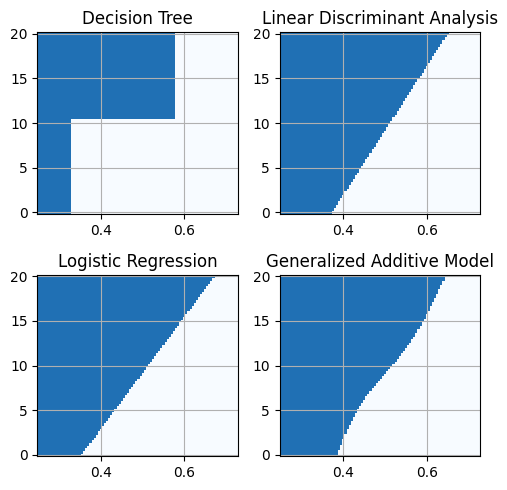

In [34]:
models = {
    'Decision Tree': loan_tree,
    'Linear Discriminant Analysis': loan_lda,
    'Logistic Regression': logit_reg,
    'Generalized Additive Model': gam,
}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))

xvalues = np.arange(0.25, 0.73, 0.005)
yvalues = np.arange(-0.1, 20.1, 0.1)
xx, yy = np.meshgrid(xvalues, yvalues)
X = pd.DataFrame({
    'borrower_score': xx.ravel(),
    'payment_inc_ratio': yy.ravel(),
})

boundary = {}

for n, (title, model) in enumerate(models.items()):
    ax = axes[n // 2, n % 2]
    predict = model.predict(X)
    if 'Generalized' in title:
        Z = np.array([1 if z > 0.5 else 0 for z in predict])
    else:

        Z = np.array([1 if z == 'default' else 0 for z in predict])
    Z = Z.reshape(xx.shape)
    boundary[title] = yvalues[np.argmax(Z > 0, axis=0)]
    boundary[title][Z[-1,:] == 0] = yvalues[-1]

    c = ax.pcolormesh(xx, yy, Z, cmap='Blues', vmin=0.1, vmax=1.3, shading='auto')
    ax.set_title(title)
    ax.grid(True)

plt.tight_layout()
plt.show()

**Figure 5-8** displays the decision regions for all four classifiers in the same two-dimensional feature space (borrower_score vs. payment_inc_ratio). Blue regions are predicted as "default" and white/light regions as "paid off."

**Decision Tree (upper-left):** Produces **rectangular, axis-aligned** regions -- it can only split along one variable at a time. The staircase-like boundary is characteristic: first it splits on borrower_score at some threshold, then on payment_inc_ratio within each branch. This creates a non-smooth but flexible boundary.

**LDA (upper-right):** Produces a perfectly **straight-line** boundary. The entire upper-left region (low borrower score, high payment ratio) is classified as default. The slope of this line is determined by the ratio of discriminant weights ($7.18 / 0.10 \approx 72$), making the boundary nearly vertical.

**Logistic Regression (lower-left):** Also produces a **straight-line** boundary, nearly identical to LDA. With only two predictors and no nonlinear terms, logistic regression and LDA converge to very similar solutions. The slight difference arises from regularization (`C=1.0` adds some shrinkage) and the different estimation methods (MLE vs. Fisher's criterion).

**GAM (lower-right):** Produces a **curved** boundary that can flex with the data. The spline terms allow each predictor to have a nonlinear effect, creating a boundary that bends rather than forming a straight line. This represents a compromise between the rigid linearity of LDA/logistic regression and the jagged rectangles of the decision tree.

**Key insight:** All four models agree on the general pattern (higher borrower score $\to$ less default, higher payment ratio $\to$ more default), but they differ in **how they draw the boundary**. The choice of model affects predictions most strongly near the boundary -- records deep in the "default" or "paid off" regions are classified identically by all methods.

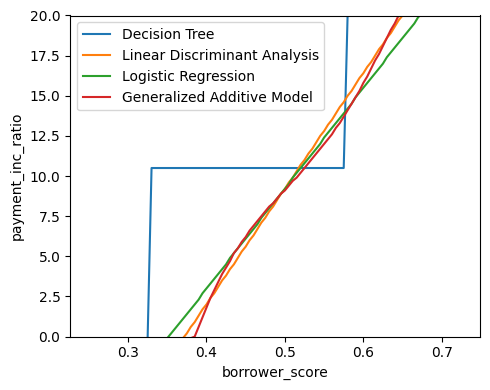

In [35]:
boundary['borrower_score'] = xvalues
boundaries = pd.DataFrame(boundary)

fig, ax = plt.subplots(figsize=(5, 4))
boundaries.plot(x='borrower_score', ax=ax)
ax.set_ylabel('payment_inc_ratio')
ax.set_ylim(0, 20)


plt.tight_layout()
plt.show()

This final plot **overlays the decision boundaries** of all four models on a single graph, making the differences crystal clear:

- **LDA and Logistic Regression** produce nearly identical straight lines -- confirming that for linear models with the same features, the two methods converge.
- **Decision Tree** creates a staircase pattern with two or three discrete steps. The abrupt jumps mean a tiny change in borrower_score can flip the prediction from "paid off" to "default" at certain thresholds.
- **GAM** traces a smooth curve that follows the general trend of the linear models but with gentle curvature. It captures the reality that the relationship between predictors and default risk may not be perfectly linear.

**Which model to choose in practice?**
- For **interpretability and speed**: logistic regression -- odds ratios are easy to explain to stakeholders, and scoring new records requires only a few multiplications.
- For **capturing nonlinear effects**: GAM or decision tree -- when the decision boundary is genuinely curved, a linear model will misclassify records near the boundary.
- For **ensembling**: decision trees -- they are the building blocks of random forests and gradient boosting (Chapter 6), which typically outperform all individual models.

The fact that LDA and logistic regression are nearly identical here is both reassuring (the models are internally consistent) and limiting (neither can capture the curvature that the GAM and tree detect). As we add more predictors and interactions, logistic regression's ability to incorporate splines and regularization gives it an edge over LDA in most practical settings.